In [1]:
import numpy as np,math
import matplotlib.pyplot as plt
import pyCloudy as pc
import os
import glob
print(pc.__version__)


# Tell pyCloudy where the executable is to be found
pc.config.cloudy_exe = '/home/jorge/cloudy-src/source/cloudy.exe'
#pc.config.cloudy_exe = '/home/jlope/Cloudy/source/cloudy.exe'



# Define the directory where the models will be run
dir_ = '../models'




#Un detalle es que en la tercera nube el Tmap es mayor que uno porque creo que se esta sumando el continuo de las dos nubes interiores y se lo estoy añadiendo a la nube segunda 
#Esto no seria del todo correcto por que esa luz extra deberia ir a la primera nube que no se representa.



#Hay que poner los ion param en funcion de la geometría.

warng pyCloudy config: pyCloudy works better with matplotlib Triangulation
warng pyCloudy config: pyCloudy works better with PyNeb
0.9.16


In [82]:
dist_earth_pc = 178000000 

pc_cm = 3.08567758e18  # 1 pc in cm
# -------------------------
# 1 Parameters of the first gas cloud.
# -------------------------
Rin_1_pc     = 0.001    # Interior radius [pc]
Rout_1_pc    = 0.05        # exterior radius [pc]
a_1_pc       = Rin_1_pc        # equatorial semiaxis a [pc]
c_1_pc       =a_1_pc        # polar semiaxis c [pc] 
r0_1_pc      = 0.001      # radius of reference for the density law [pc]
n0_1         = 1e10        # density at r0 [cm^-3]
alpha_1      = 1.0       # radial exponent for the density law.
C_1          = 100.        # contrast between equator and pole at r0 (Not used)
sigma_1_rad  = 0.2       # angular thickness (rad) (Not used)
sigma_1_deg  = sigma_1_rad * 180.0 / np.pi
T_1_K        = 1e3        # typical temperature [K] (Not used)
stop_logNH_1 = 22.0       # stop column density (log10 N_H / cm^-2)
thickness_1  = (Rout_1_pc) / Rin_1_pc
ion_param_1 = -2.0
stop_temp_1 = 100.0
metals_1 = 0.0
lum_1 = 46.0

# cm conversion.
a_1_cm    = a_1_pc * pc_cm
c_1_cm    = c_1_pc * pc_cm
Rin_1_cm  = Rin_1_pc * pc_cm
Rout_1_cm = Rout_1_pc * pc_cm
r0_1_cm   = r0_1_pc * pc_cm
dist_earth_cm = 1.78e8 * pc_cm 

# -------------------------
# 2: Second cloud parameters.
# -------------------------
Rin_2_pc     = 0.1        # interior radius [pc]
Rout_2_pc    = 1.0       # exterior radius [pc]
a_2_pc       = Rin_2_pc      # equatorial semiaxis a [pc]
c_2_pc       = a_2_pc        # polar semiaxis c [pc] 
r0_2_pc      = 1.0       # radius of reference for the density law [pc]
n0_2         = 2e4       # density at r0 [cm^-3]
alpha_2      = 1.0        # radial exponent
C_2          = 10.0       # contrast between equator and pole at r0 (Not used)
sigma_2_rad  = 0.50       # angular thickness (rad) (Not used)
sigma_2_deg  = sigma_2_rad * 180.0 / np.pi
T_2_K        = 1e4        # typical temperature [K] (Not used)
stop_logNH_2 = 24.0       # stop column density (log10 N_H / cm^-2)
thickness_2  = (Rout_2_pc) / Rin_2_pc
ion_param_2 = -10.
stop_temp_2 = 0.1
metals_2 = 1.0
dust_2 = 1.0



# cm conversion.
a_2_cm    = a_2_pc * pc_cm
c_2_cm    = c_2_pc * pc_cm
Rin_2_cm  = Rin_2_pc * pc_cm
Rout_2_cm = Rout_2_pc * pc_cm
r0_2_cm   = r0_2_pc * pc_cm


# -------------------------
# 3 Third cloud parameters.
# -------------------------
Rin_3_pc     = 100.0        # interior radius [pc]
Rout_3_pc    = 1000.0       # exterior radius [pc]
a_3_pc       = Rin_3_pc      # equatorial semiaxis a [pc]
c_3_pc       = a_3_pc        # polar semiaxis c [pc] 
r0_3_pc      = 100.0       # radius of reference for the density law [pc]
n0_3         = 5e3       # density at r0 [cm^-3]
alpha_3      = 1.0        # radial exponent
C_3          = 10.0       # contrast between equator and pole at r0 (Not used)
sigma_3_rad  = 0.50       # angular thickness (rad) (Not used)
sigma_3_deg  = sigma_3_rad * 180.0 / np.pi
T_3_K        = 1e4        # typical temperature [K] (Not used)
stop_logNH_3 = 28.0       # stop column density (log10 N_H / cm^-2)
thickness_3  = (Rout_3_pc) / Rin_3_pc
ion_param_3 = -7.
stop_temp_3 = 1.0
metals_3 = 0.0

# cm conversion.
a_3_cm    = a_3_pc * pc_cm
c_3_cm    = c_3_pc * pc_cm
Rin_3_cm  = Rin_3_pc * pc_cm
Rout_3_cm = Rout_3_pc * pc_cm
r0_3_cm   = r0_3_pc * pc_cm



In [17]:
def plots(m3d, proj_axis):
    #This function is the one used to plot ONLY the emissivity off one gas Cloud alone.
    plt.subplot(331)
    plt.imshow(m3d.get_emis('H__1_121567A').sum(axis = proj_axis)*
               m3d.cub_coord.cell_size)
    plt.title('Ly')
    plt.colorbar()
    
    plt.subplot(332)
    plt.imshow(m3d.get_emis('H__1_656281A').sum(axis = proj_axis)*
               m3d.cub_coord.cell_size)
    plt.title('Alpha')
    plt.colorbar()

def plotslog2(m3d, proj_axis):
    #This function makes is only usefull to make a really crude estimation of the emissivity in log scale.
    #In most cases it will not work correctly so please AVOID USING IT.
    eps=0.01
    plt.subplot(331)
    plt.imshow(np.log10((m3d.get_emis('H__1_121567A').sum(axis = proj_axis)*
               m3d.cub_coord.cell_size)+eps))
    plt.title('Ly')
    plt.colorbar()
    
    plt.subplot(332)
    plt.imshow(np.log10((m3d.get_emis('H__1_656281A').sum(axis = proj_axis)*
               m3d.cub_coord.cell_size)+eps))
    plt.title('Alpha')
    plt.colorbar()

def plotslog(m3d, proj_axis):
    #This one is used to plot ONLY the emissivity of one gas cloud but in Log scale. It is more robust than the previous one but it may still not be perfect in all cases.
    #Even do it may not be really precise in some cases, it is really helpful to visualice the geometry of our clouds.

    plt.figure(figsize=(18,12))

    # --- Lyman ---
    img_ly = m3d.get_emis('H__1_121567A').sum(axis=proj_axis) * m3d.cub_coord.cell_size

    # We calculate a relative eps: small compared to the minimum positive of the image, it is necessary to do it this one to avoid problems when plotting the log.
    pos = img_ly[img_ly > 0]
    if pos.size > 0:
        eps = pos.min() * 1e-2  
    # We take this relative eps as 1% of the minimum positive value in the image -> adjustable (1e-3 .. 1e-1). 
    # This isn't really physical but it is necessary to avoid issues with log(0) and as it is added to all the values of the pixels in the images, it doesn't change the relative differences between them, just avoids the log(0) problem.
    else:
        eps = 1e-30              # fallback if everything is zero.
    log_ly = np.log10(img_ly + eps)

    # we avoid that outliers dominate the palette using percentiles (we use the 1st and 99.5th percentiles to set the limits of the color scale, which can be adjusted if needed).
    vmin_ly = np.percentile(log_ly[~np.isnan(log_ly)], 1.0)
    vmax_ly = np.percentile(log_ly[~np.isnan(log_ly)], 99.5)

    plt.subplot(331)
    plt.imshow(log_ly, origin='lower', aspect='equal', vmin=vmin_ly, vmax=vmax_ly)
    plt.title('Ly (log10)')
    plt.colorbar()

    # --- Halpha (exactly the same) ---
    img_ha = m3d.get_emis('H__1_656281A').sum(axis=proj_axis) * m3d.cub_coord.cell_size

    pos = img_ha[img_ha > 0]
    if pos.size > 0:
        eps2 = pos.min() * 1e-2
    else:
        eps2 = 1e-30
    log_ha = np.log10(img_ha + eps2)

    vmin_ha = np.percentile(log_ha[~np.isnan(log_ha)], 1.0)
    vmax_ha = np.percentile(log_ha[~np.isnan(log_ha)], 99.5)

    plt.subplot(332)
    plt.imshow(log_ha, origin='lower', aspect='equal', vmin=vmin_ha, vmax=vmax_ha)
    plt.title('Alpha (log10)')
    plt.colorbar()

    plt.tight_layout()
    plt.show()

def plots3(list_inner, list_outer, dim, proj_axis, angles, rel_teo):
    # This function makes an image of the emission of an outer gas cloud and the TRANSMITTED continuum of an inner gas cloud, together.
    # To do so, it finds the fraction of the light of the inner cloud that is transmitted through the outer cloud in each direction, and then it attenuates the emissivity of the inner cloud by that fraction before adding it to the emissivity of the outer cloud.

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.ndimage import zoom
    from scipy.ndimage import rotate

    lambda_ly = 1215.67
    lambda_ha = 6562.81

    # -------------- We build a 3D map for every list of models being each cloud ---------------
    # Dims and Angles MUST BE THE SAME FOR BOTH CLOUDS, otherwise the projection and the Tmap won't be correct.
    m3d_inner = pc.C3D(list_inner, dims=[dim, dim, dim], angles=angles, plan_sym=True)
    m3d_outer = pc.C3D(list_outer, dims=[dim, dim, dim], angles=angles, plan_sym=True)

    # -------------- We obtain the 3D images of each cloud's emission ---------------
    img_inner_gas = m3d_inner.get_emis('H__1_121567A').sum(axis=proj_axis) * m3d_inner.cub_coord.cell_size
    img_outer_gas = m3d_outer.get_emis('H__1_121567A').sum(axis=proj_axis) * m3d_outer.cub_coord.cell_size

    img_inner_ha = m3d_inner.get_emis('H__1_656281A').sum(axis=proj_axis) * m3d_inner.cub_coord.cell_size
    img_outer_ha = m3d_outer.get_emis('H__1_656281A').sum(axis=proj_axis) * m3d_outer.cub_coord.cell_size

    # -------------- We calculate the transmitted continuum of the first cloud through the second one in each direction ---------------
    # For each model we calculate the fraction of the light that is transmitted through the outer cloud at the wavelength of interest (Lyman alpha and Halpha);
    n_models_outer = len(list_outer)
    T_outer_ly = np.zeros(n_models_outer, dtype=float)
    T_outer_ha = np.zeros(n_models_outer, dtype=float)

    for k, m in enumerate(list_outer):
        cont_x = m.get_cont_x(unit='Ang')        # for each wavelength (Å)
        if cont_x is None:
            T_outer_ly[k] = 0.0
            T_outer_ha[k] = 0.0
            continue

        # 'ntrans' = transmitted part of the incident SED (direct transmitted)
        trans_n = m.get_cont_y(cont='ntrans', unit='es')   # erg s^-1 cm^-2 A^-1
        incid = m.get_cont_y(cont='incid', unit='es')      # erg s^-1 cm^-2 A^-1

        if trans_n is None or incid is None:
            T_outer_ly[k] = 0.0
            T_outer_ha[k] = 0.0
            continue

        # closest indices in the grid
        i_ly = int(np.argmin(np.abs(cont_x - lambda_ly))) # We try to calculate the index of the wavelength closest to Lyman alpha and Halpha in the continuum grid of the model, to extract the transmitted fraction at those wavelengths.
        i_ha = int(np.argmin(np.abs(cont_x - lambda_ha)))
        eps = 1e-300
        T_outer_ly[k] = float(trans_n[i_ly]) / (float(incid[i_ly]) + eps) # Fraction of the transmitted light for each model.
        T_outer_ha[k] = float(trans_n[i_ha]) / (float(incid[i_ha]) + eps)


    theta_proj = m3d_outer.cub_coord.theta.mean(axis=proj_axis) # We find the mean angle for each model.

    # We make sure the theta_proj is 2D and has the same shape as the images, if it is a scalar or 1D we expand it to 2D with the same value for all pixels.
    ny, nx = img_outer_gas.shape
    if np.isscalar(theta_proj) or getattr(theta_proj, 'ndim', 0) == 0:
        theta_proj = np.ones((ny, nx), dtype=float) * float(theta_proj)

    model_thetas_outer = np.array([getattr(mm, 'theta', np.nan) for mm in list_outer], dtype=float)
    valid_mask = ~np.isnan(model_thetas_outer)
    valid_thetas = model_thetas_outer[valid_mask] 

    if valid_thetas.size > 1:
        sorted_t = np.sort(valid_thetas)
        diffs = np.abs(np.diff(sorted_t))
        sigma = float(max(np.median(diffs), 1e-6))
    else:
        sigma = 1e-3

    # build differences and weights (Gaussian in theta), normalized per pixel
    dtheta = theta_proj[:, :, None] - model_thetas_outer[None, None, :]
    weights = np.exp(-0.5 * (dtheta / sigma)**2)
    weights_sum = weights.sum(axis=2, keepdims=True) + 1e-12
    weights /= weights_sum

    # build Tmap (e.g. to attenuate inner) using those weights (same as in your previous version)
    Tmap_ly = (weights * T_outer_ly[None, None, :]).sum(axis=2)
    Tmap_ha = (weights * T_outer_ha[None, None, :]).sum(axis=2)
    np.savetxt(f"{dir_}/Tmap_NOrflec_ly.txt", Tmap_ly, fmt="%.6e")


    # -------------- ATTENUATE the inner emissivity by the outer transmission ---------------
    img_inner_atten_ly = img_inner_gas * Tmap_ly
    img_inner_atten_ha = img_inner_ha * Tmap_ha

    # ---------- minimal function to estimate radius in pixels ----------
    def _rad_px(img, thr_frac=0.05):
        im = np.array(img, dtype=float)
        cy, cx = im.shape[0]//2, im.shape[1]//2
        peak = im.max() if im.max() > 0 else 1.0
        mask = im >= (peak * thr_frac)
        if not mask.any():
            return 0.0
        ys, xs = np.nonzero(mask)
        rpx = np.sqrt(((ys - cy)**2 + (xs - cx)**2).max())
        return rpx

    r_out_px = _rad_px(img_outer_gas)
    r_in_px  = _rad_px(img_inner_atten_ly)

    # ---------- try to calculate desired_ratio automatically (better if you know the real value) ----------
    def _extract_model_radius_linear(m):
        for attr in ('radius','r_out','radii','radii_cm'):
            val = getattr(m, attr, None)
            if val is None:
                continue
            try:
                if hasattr(val, '__len__'):
                    v = float(val[-1])
                else:
                    v = float(val)
                if 0 < v < 50:
                    return 10.0**v
                else:
                    return v
            except Exception:
                continue
        return None

    outer_rads = [_extract_model_radius_linear(m) for m in list_outer]
    inner_rads = [_extract_model_radius_linear(m) for m in list_inner]
    outer_rads = [r for r in outer_rads if r is not None]
    inner_rads = [r for r in inner_rads if r is not None]
    if len(outer_rads) > 0 and len(inner_rads) > 0:
        desired_ratio = float(np.mean(outer_rads)) / float(np.mean(inner_rads))
    else:
        desired_ratio = rel_teo

    # --- minimal rescaling and pasting ---
    if r_out_px > 0 and r_in_px > 0 and desired_ratio > 0:
        new_r_in_px = r_out_px / desired_ratio
        scale = float(new_r_in_px) / float(r_in_px) if r_in_px > 0 else 1.0
        if scale <= 0:
            scale = 1.0
        inner_resized_ly = zoom(img_inner_atten_ly, zoom=scale, order=1)
        inner_resized_ha = zoom(img_inner_atten_ha, zoom=scale, order=1)

        canvas_ly = img_outer_gas.copy().astype(float)
        canvas_ha = img_outer_ha.copy().astype(float)

        cy, cx = canvas_ly.shape[0]//2, canvas_ly.shape[1]//2
        hy, wx = inner_resized_ly.shape[0]//2, inner_resized_ly.shape[1]//2
        y0, y1 = cy - hy, cy - hy + inner_resized_ly.shape[0]
        x0, x1 = cx - wx, cx - wx + inner_resized_ly.shape[1]

        sy0, sx0 = 0, 0
        sy1, sx1 = inner_resized_ly.shape[0], inner_resized_ly.shape[1]
        if y0 < 0:
            sy0 = -y0; y0 = 0
        if x0 < 0:
            sx0 = -x0; x0 = 0
        if y1 > canvas_ly.shape[0]:
            sy1 -= (y1 - canvas_ly.shape[0]); y1 = canvas_ly.shape[0]
        if x1 > canvas_ly.shape[1]:
            sx1 -= (x1 - canvas_ly.shape[1]); x1 = canvas_ly.shape[1]

        np.savetxt(f"{dir_}/inner_resized_ly.txt", inner_resized_ly, fmt="%.6e")
        canvas_ly[y0:y1, x0:x1] += inner_resized_ly[sy0:sy1, sx0:sx1]
        canvas_ha[y0:y1, x0:x1] += inner_resized_ha[sy0:sy1, sx0:sx1]

        img_combined_ly = canvas_ly
        img_combined_ha = canvas_ha
    else:
        img_combined_ly = img_outer_gas + img_inner_atten_ly
        img_combined_ha = img_outer_ha + img_inner_atten_ha
        print("Could not rescale: using direct sum.")
        
    #We save as .txt some of the images t make it easier to find any error in the rescaling and pasting process, as well as to have the data for further analysis if needed.
    np.savetxt(f"{dir_}/img_outer_ly.txt", img_outer_gas, fmt="%.6e")
    np.savetxt(f"{dir_}/img_inner_ly.txt", img_inner_atten_ly, fmt="%.6e")
    np.savetxt(f"{dir_}/img_combined_ly.txt", img_combined_ly, fmt="%.6e")

    # rotate 90° counterclockwise (CCW)
    img_combined_ha = rotate(img_combined_ha, angle=45, reshape=False)
    img_combined_ly = rotate(img_combined_ly, angle=45, reshape=False)
    eps = 0.01
    log_ha = np.log10(img_combined_ha + eps)
    log_ly = np.log10(img_combined_ly + eps)

    # -------------- visualize ---------------
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.title('Ly')
    plt.imshow(img_combined_ly, origin='lower', aspect='equal')
    plt.colorbar()
    plt.subplot(1,2,2)
    plt.title('alpha ')
    plt.imshow(img_combined_ha, origin='lower', aspect='equal')
    plt.colorbar()
    plt.show()
    np.savetxt(f"{dir_}/img_final_sinrefl_ly.txt", img_combined_ly, fmt="%.6e")
    return img_combined_ha, img_combined_ly

def _rad_px_robust(img, thr_frac=0.05, thr_absolute=None):
    #This function is used to automaticly find the radius of a cloud in pixels.
    """
    Parameters:
    -----------
    thr_frac : float
        Fraction of the peak (0.05 = 5%)
    thr_absolute : float, optional
        Absolute threshold in units of luminosity.
        If provided, it is used instead of thr_frac.
    """
    
    im = np.array(img, dtype=float)
    cy, cx = im.shape[0]//2, im.shape[1]//2
    
    if thr_absolute is not None:
        # use absolute threshold (more robust)
        threshold = thr_absolute
    else:
        # use relative threshold to peak
        peak = im.max() if im.max() > 0 else 1.0
        threshold = peak * thr_frac
    
    mask = im >= threshold
    
    if not mask.any():
        # if no pixels, use even lower threshold
        threshold = np.percentile(im[im > 0], 10) if (im > 0).any() else 0
        mask = im >= threshold
        
        if not mask.any():
            return 0.0
    
    ys, xs = np.nonzero(mask)
    rpx = np.sqrt(((ys - cy)**2 + (xs - cx)**2).max())
    return rpx


def _extract_model_radius_robust(model):
    """
    Extracts the radius of a model in cm, trying different attributes and handling cases where it might be in log or linear scale, or given as an array. It is more robust than the previous version and should work better for a wider range of models.
    """
    import numpy as np
    
    
    for attr in ('r_out', 'radius', 'radii', 'radii_cm'):
        val = getattr(model, attr, None)
        if val is None:
            continue
        
        try:
            if hasattr(val, '__len__'):
                
                v = float(val[-1])
            else:
                v = float(val)
            
            
            if 0 < v < 50:
                return 10.0**v  
            else:
                return v  
        except Exception:
            continue
    
    return None



def plots3_simple_FIXED(list_inner, list_outer, dim, proj_axis, angles, rel_teo):
    #This function should be used better than plots 3 as it works better and doesn´t fail as often.
    """
    
    This function:
    1. Creates 3D models of inner and outer clouds
    2. Calculates emission maps for Lyα and Hα
    3. Computes transmission through the outer cloud
    4. Attenuates inner cloud emission by outer transmission fraction
    5. Rescales inner cloud to correct physical size
    6. Combines both emissions into final images
    """
    from scipy.ndimage import zoom, rotate

    lambda_ly = 1215.67
    lambda_ha = 6562.81
    eps = 1e-300

    # ========== STEP 1: Build 3D models ==========
    # Create 3D cubes for both inner and outer clouds
    m3d_inner = pc.C3D(list_inner, dims=[dim, dim, dim], angles=angles, plan_sym=True)
    m3d_outer = pc.C3D(list_outer, dims=[dim, dim, dim], angles=angles, plan_sym=True)

    # ========== STEP 2: Extract cell size (physical scale) ==========
    # Get cell_size from the models (represents physical size of each voxel)
    cs_raw_inner = getattr(m3d_inner.cub_coord, 'cell_size', None)
    cs_raw_outer = getattr(m3d_outer.cub_coord, 'cell_size', None)
    cs_raw = cs_raw_outer if cs_raw_outer is not None else cs_raw_inner
    
    if cs_raw is None:
        raise RuntimeError("Could not obtain cell_size")
    
    cs_raw = float(cs_raw)
    
    # If cell_size is volume (>1e30), take cubic root to get linear size
    if cs_raw > 1e30:
        cell_linear = cs_raw ** (1.0/3.0)
    else:
        cell_linear = cs_raw
    
    print(f"\n{'='*80}")
    print(f"GEOMETRY")
    print(f"{'='*80}")
    print(f"  cell_linear: {cell_linear:.6e} cm")

    # ========== STEP 3: Calculate emission maps ==========
    # Compute volume of each voxel
    V_voxel = cell_linear**3
    
    # Get emissivity and integrate along projection axis, multiplied by voxel volume
    img_inner_gas = m3d_inner.get_emis('H__1_121567A').sum(axis=proj_axis) * V_voxel
    img_outer_gas = m3d_outer.get_emis('H__1_121567A').sum(axis=proj_axis) * V_voxel
    img_inner_ha = m3d_inner.get_emis('H__1_656281A').sum(axis=proj_axis) * V_voxel
    img_outer_ha = m3d_outer.get_emis('H__1_656281A').sum(axis=proj_axis) * V_voxel

    print(f"\nEMISSIVITY:")
    print(f"  L_inner (Lyα): {np.sum(img_inner_gas):.6e} erg/s")
    print(f"  L_outer (Lyα): {np.sum(img_outer_gas):.6e} erg/s")

    # ========== STEP 4: Calculate transmission through outer cloud ==========
    # For each outer model, compute the fraction of light transmitted at Lyα and Hα wavelengths
    n_models_outer = len(list_outer)
    T_outer_ly = np.zeros(n_models_outer, dtype=float)
    T_outer_ha = np.zeros(n_models_outer, dtype=float)

    for k, m in enumerate(list_outer):
        # Get continuum wavelength grid
        cont_x = m.get_cont_x(unit='Ang')
        if cont_x is None:
            T_outer_ly[k] = 0.0
            T_outer_ha[k] = 0.0
            continue

        # Get transmitted and incident continuum spectra
        trans_n = m.get_cont_y(cont='ntrans', unit='es')  # transmitted spectrum
        incid = m.get_cont_y(cont='incid', unit='es')     # incident spectrum
        if trans_n is None or incid is None:
            T_outer_ly[k] = 0.0
            T_outer_ha[k] = 0.0
            continue

        # Find indices closest to Lyα and Hα wavelengths
        i_ly = int(np.argmin(np.abs(cont_x - lambda_ly)))
        i_ha = int(np.argmin(np.abs(cont_x - lambda_ha)))
        
        # Calculate transmission fraction: T = transmitted / incident
        T_outer_ly[k] = float(trans_n[i_ly]) / (float(incid[i_ly]) + eps)
        T_outer_ha[k] = float(trans_n[i_ha]) / (float(incid[i_ha]) + eps)

    # ========== STEP 5: Create transmission map ==========
    # Map transmission values to each pixel based on viewing angle (theta)
    theta_proj = m3d_outer.cub_coord.theta.mean(axis=proj_axis)
    ny, nx = img_outer_gas.shape
    
    # Ensure theta_proj is 2D with same shape as images
    if np.isscalar(theta_proj) or getattr(theta_proj, 'ndim', 0) == 0:
        theta_proj = np.ones((ny, nx), dtype=float) * float(theta_proj)

    # Get theta values from each model
    model_thetas = np.array([getattr(mm, 'theta', np.nan) for mm in list_outer], dtype=float)
    model_thetas = np.nan_to_num(model_thetas, nan=0.0)

    # Find nearest model for each pixel based on theta
    dtheta = theta_proj[:, :, None] - model_thetas[None, None, :]
    dist2 = dtheta**2
    map_idx = np.argmin(dist2, axis=2)

    # Create transmission maps by indexing with nearest model
    Tmap_ly = T_outer_ly[map_idx]
    Tmap_ha = T_outer_ha[map_idx]

    np.savetxt(f"{dir_}/Tmap_ha2.txt", Tmap_ha, fmt="%.6e")

    # ========== STEP 6: Attenuate inner cloud emission ==========
    # Multiply inner emission by transmission to account for absorption by outer cloud
    img_inner_atten_ly = img_inner_gas * Tmap_ly
    img_inner_atten_ha = img_inner_ha * Tmap_ha

    print(f"\nATTENUATION:")
    print(f"  L_inner attenuated (Lyα): {np.sum(img_inner_atten_ly):.6e} erg/s")
    print(f"  Mean transmission: {Tmap_ly.mean():.6f}")

    # ========== STEP 7: Extract physical radii from models ==========
    # KEY: USE PHYSICAL RADII to determine correct scaling
    
    outer_rads = [_extract_model_radius_robust(m) for m in list_outer]
    inner_rads = [_extract_model_radius_robust(m) for m in list_inner]
    
    outer_rads = [r for r in outer_rads if r is not None]
    inner_rads = [r for r in inner_rads if r is not None]
    
    print(f"\nPHYSICAL RADII:")
    print(f"  R_outer (from models): {outer_rads}")
    print(f"  R_inner (from models): {inner_rads}")
    
    if len(outer_rads) > 0 and len(inner_rads) > 0:
        # Calculate mean radii
        R_outer_mean_cm = np.mean(outer_rads)
        R_inner_mean_cm = np.mean(inner_rads)
        
        # Physical size ratio
        ratio_physical = R_outer_mean_cm / R_inner_mean_cm
        
        print(f"  R_outer (mean): {R_outer_mean_cm:.6e} cm")
        print(f"  R_inner (mean): {R_inner_mean_cm:.6e} cm")
        print(f"  Physical ratio: {ratio_physical:.3f}")
        
        # ========== STEP 8: Convert to pixel coordinates ==========
        # The grid has `dim` pixels covering approximately 2*R_outer in physical size
        
        # Outer radius in pixels (approximated as half the grid)
        r_out_px = dim / 2.0  # pixels
        
        # Inner radius in pixels (using physical ratio)
        r_in_px_expected = r_out_px / ratio_physical
        
        print(f"\nRADII IN PIXELS (expected):")
        print(f"  r_out_px: {r_out_px:.1f} pixels")
        print(f"  r_in_px (expected): {r_in_px_expected:.1f} pixels")
        
        # ========== STEP 9: Detect actual inner radius in image ==========
        # ROBUST DETECTION of inner radius in the image
        # Use low threshold to capture all emission
        def _rad_px_robust(img):
            im = np.array(img, dtype=float)
            cy, cx = im.shape[0]//2, im.shape[1]//2
            
            # Use 50th percentile as threshold (more robust)
            threshold = np.percentile(im[im > 0], 50) if (im > 0).any() else 0
            
            mask = im >= threshold
            if not mask.any():
                # Fallback: use any pixel with emission
                mask = im > 0
                if not mask.any():
                    return 0.0
            
            ys, xs = np.nonzero(mask)
            rpx = np.sqrt(((ys - cy)**2 + (xs - cx)**2).max())
            return rpx
        
        r_in_px_detected = _rad_px_robust(img_inner_atten_ly)
        
        print(f"  r_in_px (detected): {r_in_px_detected:.1f} pixels")
        
        # ========== STEP 10: Calculate scaling factor ==========
        # We want r_in_px_detected to transform to r_in_px_expected
        if r_in_px_detected > 0:
            scale = r_in_px_expected / r_in_px_detected
        else:
            # Fallback: use physical ratio directly
            scale = 1.0 / ratio_physical
        
        print(f"  Scaling factor: {scale:.3f}")
        
    else:
        # Fallback: use rel_teo if no radii available in models
        print(f"\n⚠️  Could not extract radii from models")
        print(f"  Using rel_teo = {rel_teo}")
        
        r_out_px = dim / 2.0
        r_in_px_expected = r_out_px / rel_teo
        r_in_px_detected = _rad_px_robust(img_inner_atten_ly)
        
        if r_in_px_detected > 0:
            scale = r_in_px_expected / r_in_px_detected
        else:
            scale = 1.0 / rel_teo

    # ========== STEP 11: Apply scaling and combine images ==========
    if scale > 0:
        # Rescale inner cloud images
        inner_resized_ly = zoom(img_inner_atten_ly, zoom=scale, order=1)
        inner_resized_ha = zoom(img_inner_atten_ha, zoom=scale, order=1)

        print(f"\nRESCALING:")
        print(f"  Original shape: {img_inner_atten_ly.shape}")
        print(f"  Rescaled shape: {inner_resized_ly.shape}")

        # Create canvas with outer cloud emission
        canvas_ly = img_outer_gas.copy().astype(float)
        canvas_ha = img_outer_ha.copy().astype(float)

        # Calculate center positions
        cy, cx = canvas_ly.shape[0]//2, canvas_ly.shape[1]//2
        hy, hx = inner_resized_ly.shape[0]//2, inner_resized_ly.shape[1]//2
        
        # Calculate placement boundaries
        y0, y1 = cy - hy, cy + (inner_resized_ly.shape[0] - hy)
        x0, x1 = cx - hx, cx + (inner_resized_ly.shape[1] - hx)

        # Initialize source boundaries
        sy0, sx0 = 0, 0
        sy1, sx1 = inner_resized_ly.shape[0], inner_resized_ly.shape[1]
        
        # Adjust boundaries if inner extends beyond canvas
        if y0 < 0:
            sy0, y0 = -y0, 0
        if x0 < 0:
            sx0, x0 = -x0, 0
        if y1 > canvas_ly.shape[0]:
            sy1, y1 = sy1 - (y1 - canvas_ly.shape[0]), canvas_ly.shape[0]
        if x1 > canvas_ly.shape[1]:
            sx1, x1 = sx1 - (x1 - canvas_ly.shape[1]), canvas_ly.shape[1]

        print(f"  Canvas region: y[{y0}:{y1}], x[{x0}:{x1}]")
        print(f"  Inner region:  y[{sy0}:{sy1}], x[{sx0}:{sx1}]")

        # Add rescaled inner emission to canvas
        canvas_ly[y0:y1, x0:x1] += inner_resized_ly[sy0:sy1, sx0:sx1]
        canvas_ha[y0:y1, x0:x1] += inner_resized_ha[sy0:sy1, sx0:sx1]

        img_combined_ly = canvas_ly
        img_combined_ha = canvas_ha
    else:
        # Direct sum if scaling failed
        img_combined_ly = img_outer_gas + img_inner_atten_ly
        img_combined_ha = img_outer_ha + img_inner_atten_ha


    # ========== STEP 12: Visualize results ==========
    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.title('Lyα')
    plt.imshow(img_combined_ly, origin='lower', cmap='viridis')
    plt.colorbar(label='L [erg/s]')
    
    plt.subplot(1,2,2)
    plt.title('Hα')
    plt.imshow(img_combined_ha, origin='lower', cmap='viridis')
    plt.colorbar(label='L [erg/s]')
    
    plt.tight_layout()
    plt.show()

    return img_combined_ha, img_combined_ly

In [18]:
def plots_reflection2_Fixed(list_inner, list_outer, dim, proj_axis, angles, rel_teo, aumenta_refl):
    """
    Fixed version with reflection weighted by emissivity.
    
    This function:
    1. Creates 3D models of inner and outer clouds
    2. Calculates emission maps for Lyα and Hα
    3. Computes transmission through outer cloud
    4. Extracts reflected continuum from outer cloud models
    5. Distributes reflected light proportionally to local emissivity (This isn't always physically accurate and therefore this images may only be used for qualitative comparison)
    (For more precise analysis of the reflected light, the spectrum should be analyse and not the images.)
    6. Attenuates inner cloud emission by outer transmission
    7. Rescales inner cloud to correct physical size
    8. Combines all contributions into final images
    
    Key features:
    - Uses emissivity-weighted average for theta projection
    - Distributes reflected continuum proportionally to local emissivity
    - Conserves energy: sum of pixels = total model luminosity
    """

    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.ndimage import zoom, rotate

    lambda_ly = 1215.67
    lambda_ha = 6562.81
    eps = 1e-300

    def _extract_model_radius_linear(m):
        """Extract physical radius from model attributes."""
        for attr in ('radius','r_out','radii','radii_cm'):
            val = getattr(m, attr, None)
            if val is None:
                continue
            try:
                if hasattr(val, '__len__'):
                    v = float(val[-1])
                else:
                    v = float(val)
                if 0 < v < 50:
                    return 10.0**v
                else:
                    return v
            except Exception:
                continue
        return None

    # ========== STEP 1: Build 3D models ==========
    m3d_inner = pc.C3D(list_inner, dims=[dim, dim, dim], angles=angles, plan_sym=True)
    m3d_outer = pc.C3D(list_outer, dims=[dim, dim, dim], angles=angles, plan_sym=True)

    # ========== STEP 2: Determine linear cell size ==========
    cs_raw_inner = getattr(m3d_inner.cub_coord, 'cell_size', None)
    cs_raw_outer = getattr(m3d_outer.cub_coord, 'cell_size', None)
    cs_raw = cs_raw_outer if cs_raw_outer is not None else cs_raw_inner
    if cs_raw is None:
        raise RuntimeError("cub_coord.cell_size not found in m3d objects.")
    cs_raw = float(cs_raw)
    
    # If cell_size is volume (>1e30), take cubic root
    if cs_raw > 1e30:
        cell_linear = cs_raw ** (1.0/3.0)
    else:
        cell_linear = cs_raw
    
    # Calculate voxel volume and pixel area
    V_voxel = cell_linear**3
    A_pix = cell_linear**2

    # ========== STEP 3: Get 3D emissivity and convert to luminosity per pixel ==========
    emis_inner = m3d_inner.get_emis('H__1_121567A')
    emis_outer = m3d_outer.get_emis('H__1_121567A')

    # Convert emissivity to luminosity per voxel
    Lvoxel_inner = emis_inner * V_voxel
    Lvoxel_outer = emis_outer * V_voxel

    # Project along viewing axis
    img_inner_gas = Lvoxel_inner.sum(axis=proj_axis)
    img_outer_gas = Lvoxel_outer.sum(axis=proj_axis)

    # Same for Hα
    emis_inner_ha = m3d_inner.get_emis('H__1_656281A')
    emis_outer_ha = m3d_outer.get_emis('H__1_656281A')
    Lvoxel_inner_ha = emis_inner_ha * V_voxel
    Lvoxel_outer_ha = emis_outer_ha * V_voxel
    img_inner_ha = Lvoxel_inner_ha.sum(axis=proj_axis)
    img_outer_ha = Lvoxel_outer_ha.sum(axis=proj_axis)

    # ========== STEP 4: Extract transmission and reflection per model ==========
    n_models_outer = len(list_outer)
    T_outer_ly = np.zeros(n_models_outer, dtype=float)
    T_outer_ha = np.zeros(n_models_outer, dtype=float)
    refl_outer_ly_Llam = np.zeros(n_models_outer, dtype=float)  # erg s^-1 Å^-1
    refl_outer_ha_Llam = np.zeros(n_models_outer, dtype=float)

    cont_x_sample = None
    for k, m in enumerate(list_outer):
        # Get wavelength grid
        cont_x = m.get_cont_x(unit='Ang')
        if cont_x is None:
            T_outer_ly[k] = 0.0
            T_outer_ha[k] = 0.0
            refl_outer_ly_Llam[k] = 0.0
            refl_outer_ha_Llam[k] = 0.0
            continue
        if cont_x_sample is None:
            cont_x_sample = np.asarray(cont_x, dtype=float)

        # Get transmission
        trans_n = m.get_cont_y(cont='ntrans', unit='es')
        incid = m.get_cont_y(cont='incid', unit='es')

        if trans_n is None or incid is None:
            T_outer_ly[k] = 0.0
            T_outer_ha[k] = 0.0
        else:
            i_ly = int(np.argmin(np.abs(cont_x - lambda_ly)))
            i_ha = int(np.argmin(np.abs(cont_x - lambda_ha)))
            T_outer_ly[k] = float(trans_n[i_ly]) / (float(incid[i_ly]) + eps)
            T_outer_ha[k] = float(trans_n[i_ha]) / (float(incid[i_ha]) + eps)

        # Get reflection
        refl_y_lam = m.get_cont_y(cont='reflec', unit='esA')  # erg s^-1 Å^-1
        if refl_y_lam is None:
            refl_outer_ly_Llam[k] = 0.0
            refl_outer_ha_Llam[k] = 0.0
        else:
            i_ly = int(np.argmin(np.abs(cont_x - lambda_ly)))
            i_ha = int(np.argmin(np.abs(cont_x - lambda_ha)))
            refl_outer_ly_Llam[k] = float(refl_y_lam[i_ly])
            refl_outer_ha_Llam[k] = float(refl_y_lam[i_ha])

    # ========== STEP 5: Calculate theta_proj with emissivity-weighted average ==========
    # Weight theta by emissivity to get more accurate angle distribution
    theta_3d = m3d_outer.cub_coord.theta
    numerator = (theta_3d * emis_outer).sum(axis=proj_axis)
    denominator = emis_outer.sum(axis=proj_axis) + 1e-30
    theta_proj = numerator / denominator

    ny, nx = img_outer_gas.shape
    if np.isscalar(theta_proj) or getattr(theta_proj, 'ndim', 0) == 0:
        theta_proj = np.ones((ny, nx), dtype=float) * float(theta_proj)

    # Get theta values from each model
    model_thetas_outer = np.array([getattr(mm, 'theta', np.nan) for mm in list_outer], dtype=float)
    model_thetas_outer = np.nan_to_num(model_thetas_outer, nan=0.0)

    # ========== STEP 6: Assign each pixel to nearest model by theta ==========
    # Discrete assignment: each pixel to closest model by theta angle
    dtheta = theta_proj[:, :, None] - model_thetas_outer[None, None, :]
    dist2 = dtheta**2
    map_idx = np.argmin(dist2, axis=2)

    # Create transmission maps
    Tmap_ly = T_outer_ly[map_idx]
    Tmap_ha = T_outer_ha[map_idx]

    # ========== STEP 7: Calculate wavelength bin width (Δλ) ==========
    if cont_x_sample is not None:
        dlam = np.diff(cont_x_sample)
        if dlam.size > 0:
            dlam = np.concatenate([dlam, dlam[-1:]])
        else:
            dlam = np.ones_like(cont_x_sample)
        i_ly = int(np.argmin(np.abs(cont_x_sample - lambda_ly)))
        delta_lambda_ly = float(abs(dlam[i_ly]))
        i_ha = int(np.argmin(np.abs(cont_x_sample - lambda_ha)))
        delta_lambda_ha = float(abs(dlam[i_ha]))
    else:
        delta_lambda_ly = 1.0
        delta_lambda_ha = 1.0

    # ========== STEP 8: Convert reflected flux density to total luminosity ==========
    # Total reflected luminosity per model (erg/s)
    # L = L_λ × Δλ
    L_model_ly = refl_outer_ly_Llam * delta_lambda_ly
    L_model_ha = refl_outer_ha_Llam * delta_lambda_ha

    # ========== STEP 9: Distribute reflection weighted by emissivity ==========
    # Key innovation: distribute reflected light proportionally to local emissivity
    # This is more physical than uniform distribution
    emis_weight_proj_ly = img_outer_gas.copy()
    emis_weight_proj_ha = img_outer_ha.copy()

    L_refl_pix_ly = np.zeros_like(img_outer_gas, dtype=float)
    L_refl_pix_ha = np.zeros_like(img_outer_ha, dtype=float)

    for k in range(n_models_outer):
        # Find pixels assigned to this model
        mask_k = (map_idx == k)
        
        if not mask_k.any():
            continue
        
        # Distribution weighted by Lyα emissivity
        weight_k_ly = emis_weight_proj_ly[mask_k]
        total_weight_k_ly = weight_k_ly.sum()
        
        if total_weight_k_ly > 0:
            # Distribute proportionally to emissivity
            L_refl_pix_ly[mask_k] = (L_model_ly[k] * weight_k_ly / total_weight_k_ly) * aumenta_refl * A_pix
        else:
            # Fallback: uniform distribution
            n_pixels_k = mask_k.sum()
            L_refl_pix_ly[mask_k] = (L_model_ly[k] / n_pixels_k) * aumenta_refl * A_pix
        
        # Distribution weighted by Hα emissivity
        weight_k_ha = emis_weight_proj_ha[mask_k]
        total_weight_k_ha = weight_k_ha.sum()
        
        if total_weight_k_ha > 0:
            L_refl_pix_ha[mask_k] = (L_model_ha[k] * weight_k_ha / total_weight_k_ha) * aumenta_refl * A_pix
        else:
            n_pixels_k = mask_k.sum()
            L_refl_pix_ha[mask_k] = (L_model_ha[k] / n_pixels_k) * aumenta_refl * A_pix

    # ========== STEP 10: Diagnostic output ==========
    print(f"\n{'='*80}")
    print(f"REFLECTION DIAGNOSTICS")
    print(f"{'='*80}")
    print(f"  theta_proj range: [{theta_proj.min():.2f}, {theta_proj.max():.2f}]")
    print(f"  Total L_model_ly: {L_model_ly.sum():.2e} erg/s")
    print(f"  Total L_refl_pix_ly: {L_refl_pix_ly.sum():.2e} erg/s")
    print(f"  Energy conservation Ly: {L_refl_pix_ly.sum() / (L_model_ly.sum() * aumenta_refl * A_pix + eps):.4f}")
    print(f"  Energy conservation Hα: {L_refl_pix_ha.sum() / (L_model_ha.sum() * aumenta_refl * A_pix + eps):.4f}")

    # Sample of first 5 models
    print(f"\n{'Theta (°)':>10} | {'N_pix':>6} | {'L_model':>12} | {'L_assigned':>12}")
    print("-" * 50)
    for k in range(min(5, n_models_outer)):
        n_pix = (map_idx == k).sum()
        refl_k = L_refl_pix_ly[map_idx == k].sum() if n_pix > 0 else 0
        print(f"{model_thetas_outer[k]:10.1f} | {n_pix:6d} | {L_model_ly[k]:12.2e} | {refl_k:12.2e}")

    # Detailed diagnostic per angle
    print(f"\n{'='*80}")
    print(f"EMISSIVITY AND REFLECTION PER ANGLE (PER PIXEL AVERAGES)")
    print(f"{'='*80}")
    print(f"{'Theta (°)':>10} | {'N_pix':>6} | {'Emis_Ly/pix':>13} | {'Emis_Ha/pix':>13} | {'Refl_Ly/pix':>13} | {'Refl_Ha/pix':>13}")
    print("-" * 90)
    
    for k in range(n_models_outer):
        mask_k = (map_idx == k)
        n_pix = mask_k.sum()
        
        if n_pix > 0:
            emis_ly_per_pix = emis_weight_proj_ly[mask_k].mean()
            emis_ha_per_pix = emis_weight_proj_ha[mask_k].mean()
            refl_ly_per_pix = L_refl_pix_ly[mask_k].mean()
            refl_ha_per_pix = L_refl_pix_ha[mask_k].mean()
        else:
            emis_ly_per_pix = 0.0
            emis_ha_per_pix = 0.0
            refl_ly_per_pix = 0.0
            refl_ha_per_pix = 0.0
        
        print(f"{model_thetas_outer[k]:10.1f} | {n_pix:6d} | {emis_ly_per_pix:13.3e} | {emis_ha_per_pix:13.3e} | {refl_ly_per_pix:13.3e} | {refl_ha_per_pix:13.3e}")
    
    # Save detailed diagnostic to file
    try:
        with open(f"{dir_}/diagnostico_por_angulo.txt", 'w') as f:
            f.write(f"{'Theta':>10} {'N_pix':>8} {'Emis_Ly/pix':>15} {'Emis_Ha/pix':>15} {'Refl_Ly/pix':>15} {'Refl_Ha/pix':>15} {'L_model_Ly':>15} {'L_model_Ha':>15}\n")
            for k in range(n_models_outer):
                mask_k = (map_idx == k)
                n_pix = mask_k.sum()
                
                if n_pix > 0:
                    emis_ly_per_pix = emis_weight_proj_ly[mask_k].mean()
                    emis_ha_per_pix = emis_weight_proj_ha[mask_k].mean()
                    refl_ly_per_pix = L_refl_pix_ly[mask_k].mean()
                    refl_ha_per_pix = L_refl_pix_ha[mask_k].mean()
                else:
                    emis_ly_per_pix = 0.0
                    emis_ha_per_pix = 0.0
                    refl_ly_per_pix = 0.0
                    refl_ha_per_pix = 0.0
                
                f.write(f"{model_thetas_outer[k]:10.2f} {n_pix:8d} {emis_ly_per_pix:15.6e} {emis_ha_per_pix:15.6e} {refl_ly_per_pix:15.6e} {refl_ha_per_pix:15.6e} {L_model_ly[k]:15.6e} {L_model_ha[k]:15.6e}\n")
    except Exception as e:
        print(f"Could not save diagnostico_por_angulo.txt: {e}")

    # ========== STEP 11: Add reflection to outer cloud emission ==========
    img_outer_gas += L_refl_pix_ly
    img_outer_ha += L_refl_pix_ha

    # ========== STEP 12: Attenuate inner cloud emission ==========
    img_inner_atten_ly = img_inner_gas * Tmap_ly
    img_inner_atten_ha = img_inner_ha * Tmap_ha

    # ========== STEP 13: Calculate scaling using physical radii ==========
    outer_rads = [_extract_model_radius_linear(m) for m in list_outer]
    inner_rads = [_extract_model_radius_linear(m) for m in list_inner]
    outer_rads = [r for r in outer_rads if r is not None]
    inner_rads = [r for r in inner_rads if r is not None]
    
    if len(outer_rads) > 0 and len(inner_rads) > 0:
        R_outer_mean_cm = np.mean(outer_rads)
        R_inner_mean_cm = np.mean(inner_rads)
        desired_ratio = float(R_outer_mean_cm / R_inner_mean_cm)
        
        r_out_px = dim / 2.0
        r_in_px_expected = r_out_px / desired_ratio
        
        def _rad_px_robust(img):
            """Robustly detect radius in image using percentile threshold."""
            im = np.array(img, dtype=float)
            cy, cx = im.shape[0]//2, im.shape[1]//2
            threshold = np.percentile(im[im > 0], 50) if (im > 0).any() else 0
            mask = im >= threshold
            if not mask.any():
                mask = im > 0
                if not mask.any():
                    return 0.0
            ys, xs = np.nonzero(mask)
            return np.sqrt(((ys - cy)**2 + (xs - cx)**2).max())
        
        r_in_px_detected = _rad_px_robust(img_inner_atten_ly)
        
        if r_in_px_detected > 0:
            scale = r_in_px_expected / r_in_px_detected
        else:
            scale = 1.0 / desired_ratio
    else:
        # Fallback to rel_teo if physical radii not available
        desired_ratio = float(rel_teo) if rel_teo is not None else 1.0
        r_out_px = dim / 2.0
        r_in_px_expected = r_out_px / desired_ratio
        
        def _rad_px_robust(img):
            im = np.array(img, dtype=float)
            cy, cx = im.shape[0]//2, im.shape[1]//2
            threshold = np.percentile(im[im > 0], 50) if (im > 0).any() else 0
            mask = im >= threshold
            if not mask.any():
                mask = im > 0
                if not mask.any():
                    return 0.0
            ys, xs = np.nonzero(mask)
            return np.sqrt(((ys - cy)**2 + (xs - cx)**2).max())
        
        r_in_px_detected = _rad_px_robust(img_inner_atten_ly)
        
        if r_in_px_detected > 0:
            scale = r_in_px_expected / r_in_px_detected
        else:
            scale = 1.0 / desired_ratio

    # ========== STEP 14: Apply scaling and combine images ==========
    if scale > 0:
        # Rescale inner cloud images
        inner_resized_ly = zoom(img_inner_atten_ly, zoom=scale, order=1)
        inner_resized_ha = zoom(img_inner_atten_ha, zoom=scale, order=1)

        # Create canvas with outer cloud
        canvas_ly = img_outer_gas.copy().astype(float)
        canvas_ha = img_outer_ha.copy().astype(float)

        # Calculate center and placement
        cy, cx = canvas_ly.shape[0]//2, canvas_ly.shape[1]//2
        hy, wx = inner_resized_ly.shape[0]//2, inner_resized_ly.shape[1]//2
        y0, y1 = cy - hy, cy - hy + inner_resized_ly.shape[0]
        x0, x1 = cx - wx, cx - wx + inner_resized_ly.shape[1]

        # Initialize boundaries
        sy0, sx0 = 0, 0
        sy1, sx1 = inner_resized_ly.shape[0], inner_resized_ly.shape[1]
        
        # Clip to canvas boundaries
        if y0 < 0:
            sy0 = -y0; y0 = 0
        if x0 < 0:
            sx0 = -x0; x0 = 0
        if y1 > canvas_ly.shape[0]:
            sy1 -= (y1 - canvas_ly.shape[0]); y1 = canvas_ly.shape[0]
        if x1 > canvas_ly.shape[1]:
            sx1 -= (x1 - canvas_ly.shape[1]); x1 = canvas_ly.shape[1]

        # Add rescaled inner to canvas
        canvas_ly[y0:y1, x0:x1] += inner_resized_ly[sy0:sy1, sx0:sx1]
        canvas_ha[y0:y1, x0:x1] += inner_resized_ha[sy0:sy1, sx0:sx1]

        img_combined_ly = canvas_ly
        img_combined_ha = canvas_ha
    else:
        # Direct sum if scaling failed
        img_combined_ly = img_outer_gas + img_inner_atten_ly
        img_combined_ha = img_outer_ha + img_inner_atten_ha

    # ========== STEP 15: Save diagnostic files ==========
    try:
        np.savetxt(f"{dir_}/img_outer_ly_reflect.txt", img_outer_gas, fmt="%.6e")
        np.savetxt(f"{dir_}/L_refl_pix_ly.txt", L_refl_pix_ly, fmt="%.6e")
        np.savetxt(f"{dir_}/Tmap_ly.txt", Tmap_ly, fmt="%.6e")
        np.savetxt(f"{dir_}/theta_proj.txt", theta_proj, fmt="%.6e")
    except Exception:
        pass

    # ========== STEP 16: Rotate and visualize ==========
    img_combined_ha = rotate(img_combined_ha, angle=45, reshape=False)
    img_combined_ly = rotate(img_combined_ly, angle=45, reshape=False)

    plt.figure(figsize=(12,6))
    plt.subplot(1,2,1)
    plt.title('Lyα')
    plt.imshow(img_combined_ly, origin='lower', aspect='equal')
    plt.colorbar()
    
    plt.subplot(1,2,2)
    plt.title('Hα')
    plt.imshow(img_combined_ha, origin='lower', aspect='equal')
    plt.colorbar()
    
    plt.show()
    
    # Save final images
    np.savetxt(f"{dir_}/img_final_ly.txt", img_combined_ly, fmt="%.6e")
    np.savetxt(f"{dir_}/img_final_ha.txt", img_combined_ha, fmt="%.6e")

    return img_combined_ha, img_combined_ly

In [86]:
def R_axisymmetric(theta_rad, a, c):
    """
    Intersection radius with the ellipsoid with a=b (symmetry around z-axis).
    
    Args:
        theta_rad: angle in radians
        a: semi-major axis (equatorial radius)
        c: semi-minor axis (polar radius)
    
    Returns:
        R: intersection radius in same units as a,c (e.g., cm)
    
    Formula: R = 1 / sqrt( sin^2(theta)/a^2 + cos^2(theta)/c^2 )
    """
    s2 = np.sin(theta_rad)**2
    c2 = np.cos(theta_rad)**2
    denom = s2/(a*a) + c2/(c*c)
    return 1.0 / np.sqrt(denom)




def make_dlaw_1(thrad, a, c, thickness, N_r, n0, r0_pc, alpha):
    """
    Creates a 'dlaw table' with N_r log-spaced points between Rint and Rext.
    
    This implements a radial density law: n(r) = n0 * (r/r0)^(-alpha)
    
    Args:
        thrad: angle in radians (as in your code: th * 2*pi/360)
        a, c, thickness: parameters for R_axisymmetric
        N_r: number of radii in the table
        n0: reference density (cm^-3) at r0
        r0_pc: reference radius in pc for the density law
        alpha: radial exponent
    
    Returns:
        List of strings with the complete dlaw table for Cloudy input
    """
    Rint_log = np.log10(R_axisymmetric(thrad, a, c))-0.01
    Rext_log = Rint_log + np.log10(1.0 + thickness) + 0.02  # small extra margin

    # radii in cm (log-spaced between 10**Rint_log and 10**Rext_log)
    radii = np.logspace(Rint_log, Rext_log, N_r)
    r0_cm = r0_pc * pc_cm

    lines = ['dlaw table',
             ]
    for r in radii:
        logr = np.log10(r)
        n = n0 * (r / r0_cm) ** (-alpha)
        lines.append(f'{logr:18.6f}    {np.log10(n):8.4f}')
    lines.append('end')
    print(lines)
    return lines

def make_dlaw_2(thrad, a, c, thickness, N_r, n0, r0_pc, alpha):
    """
    Creates a 'dlaw table' with angular dependence: n(r,theta) = n0 * (r/r0)^(-alpha) * cos^4(theta)
    
    This implements both radial and angular density variations for the second cloud (torus).
    The cos^4(theta) factor concentrates density toward the equator.
    
    Args:
        thrad: angle in radians
        a, c, thickness: parameters for R_axisymmetric
        N_r: number of radii in the table
        n0: reference density (cm^-3) at r0
        r0_pc: reference radius in pc
        alpha: radial exponent
    
    Returns:
        List of strings with the complete dlaw table
    """
    Rint_log = np.log10(R_axisymmetric(thrad, a, c))-0.01
    Rext_log = Rint_log + np.log10(1.0 + thickness) + 0.02

    radii = np.logspace(Rint_log, Rext_log, N_r)
    r0_cm = r0_pc * pc_cm

    lines = ['dlaw table',
             ]
    for r in radii:
        logr = np.log10(r)
        n = n0 * (r / r0_cm) ** (-alpha)
        # Angular modulation with cos^4(theta) - peaks at equator
        lines.append(f'{logr:18.6f}    {np.log10(n)*(np.cos(thrad)**4):8.4f}')
    lines.append('end')
    print(lines)
    return lines

def make_dlaw_3(thrad, a, c, thickness, N_r, n0, r0_pc, alpha):
    """
    Creates a 'dlaw table' with angular dependence: n(r,theta) = n0 * (r/r0)^(-alpha) * cos^4(theta - pi/2)
    
    This implements density variation for the third cloud (NLR).
    The cos^4(theta - pi/2) factor concentrates density toward the polar axis.
    
    Args:
        thrad: angle in radians
        a, c, thickness: parameters for R_axisymmetric
        N_r: number of radii in the table
        n0: reference density (cm^-3) at r0
        r0_pc: reference radius in pc
        alpha: radial exponent
    
    Returns:
        List of strings with the complete dlaw table
    """
    Rint_log = np.log10(R_axisymmetric(thrad, a, c))-0.01
    Rext_log = Rint_log + np.log10(1.0 + thickness) + 0.02

    radii = np.logspace(Rint_log, Rext_log, N_r)
    r0_cm = r0_pc * pc_cm

    lines = ['dlaw table',
             ]
    for r in radii:
        logr = np.log10(r)
        n = n0 * (r / r0_cm) ** (-alpha)
        # Angular modulation with cos^4(theta - pi/2) - peaks at poles
        lines.append(f'{logr:18.6f}    {np.log10(n)*(np.cos(thrad-(np.pi/2))**4):8.4f}')
    lines.append('end')
    print(lines)
    return lines




def set_models(model_name, N, thickness, a, c, emis_tab, N_r, alpha, n0, r0_pc, C, sigma_rad, stop_logNH_1, ion_param_1, stop_temp_1, metals_1, lum_1):
    """
    Creates Cloudy input files for the first cloud (inner BLR/AGN region).
    
    This function:
    1. Generates a grid of models at different theta angles
    2. Sets up spherical geometry with ellipsoidal boundaries
    3. Applies constant density (could use dlaw_1 if uncommented)
    4. Configures AGN illumination and stopping criteria
    5. Saves transmitted continuum for use by outer clouds
    
    Args:
        model_name: base name for output files
        N: number of theta angles
        thickness: fractional thickness of shell
        a, c: ellipsoid semi-axes
        emis_tab: emission table configuration
        N_r: number of radial points for dlaw
        alpha: density power-law index
        n0: reference density (cm^-3)
        r0_pc: reference radius (pc)
        C, sigma_rad: (unused legacy parameters)
        stop_logNH_1: log of stopping column density
        ion_param_1: ionization parameter (log U or log xi)
    """
    ntheta = N
    nphi = 2*N
    theta = np.linspace(-90., 90., ntheta)
    phi = np.linspace(0., 360., nphi)

    model_th = pc.CloudyInput()

    for th in theta:
        # Create unique model for each angle
        varname = f"model_{round(th)}"
        model_th = pc.CloudyInput()
        model_th.model_name = '{0}/{1}_{2:.0f}'.format(dir_, model_name, th)
        
        # Calculate inner and outer radii based on angle
        thrad = th * 2*np.pi/360
        Rint = np.log10(R_axisymmetric(thrad, a, c))
        Rext = round(Rint + np.log10(1.0 + thickness), 6)
        
        # Set up Cloudy parameters
        parameters = [
            'title "FBQS0751"',
            f'luminosity total {lum_1}', 
            'table AGN',  # MF87 AGN spectrum
            f"stop radius {Rext}",
            f'stop temperature {stop_temp_1} K',
            f'metals {metals_1}',
            'COSMIC RAYS BACKGROUND',
            #'set continuum resolution 0.1',
            #'compile grains',
            f'stop neutral column density {stop_logNH_1}',
            #f'ionization parameter = {ion_param_1}',
            'no level2',              
            'no fine structure',      
            'no molecules',
        ]
        model_th.set_other(parameters)
        model_th.set_emis_tab(emis_tab)
        model_th.set_distance(dist_earth_pc/1000.)
       

        # Density law (currently using constant density)
        #dlaw = make_dlaw_1(thrad, a, c, thickness, N_r,
                          #n0=n0, r0_pc=r0_pc, alpha=alpha)
        d = np.log10(n0)
        print(d)
        model_th.set_cste_density(d)
        # model_th.set_other(dlaw)  # Uncomment to use radial density law
        
        # Geometry configuration
        model_th.set_other(('sphere',))
        model_th.set_other((f"radius {Rint} {Rext}",))
        model_th.set_theta_phi(th)
        
        # Save transmitted continuum for next cloud
        model_th.set_other(('save transmitted continuum file =".txt"'))

        model_th.print_input(to_file=True, verbose=False)
        globals()[varname] = model_th
        print(th)






def set_models_second(model_name, model_name2, N, thickness, a, c, emis_tab, N_r, alpha, n0, r0_pc, C, sigma_rad, stop_logNH_2, ion_param_2, metals_2, stop_temp_2,dust_2):
    """
    Creates Cloudy input files for the second cloud (torus/skin region).
    
    This function:
    1. Reads transmitted continuum from first cloud as incident spectrum
    2. Generates models at different theta angles
    3. Applies angular density variation (cos^7 theta) concentrated at equator
    4. Could use dlaw_2 for more detailed radial structure
    5. Saves transmitted continuum for third cloud
    
    This cloud represents the geometrically thick torus with its outflowing skin,
    as described in the papers for SDSS J1652.
    
    Args:
        model_name: name of first cloud (for reading transmitted continuum)
        model_name2: base name for output files
        N: number of theta angles
        thickness: fractional thickness of shell
        a, c: ellipsoid semi-axes
        emis_tab: emission table configuration
        N_r: number of radial points for dlaw
        alpha: density power-law index
        n0: reference density (cm^-3)
        r0_pc: reference radius (pc)
        C, sigma_rad: (unused legacy parameters)
        stop_logNH_2: log of stopping column density
        ion_param_2: ionization parameter
    """
    ntheta = N
    theta = np.linspace(-90., 90., ntheta)

    model2 = pc.CloudyInput()

    for th in theta:
        varname = f"model2_{round(th)}"

        # Read transmitted continuum from first cloud
        trans_name_angle = '{0}/{1}_{2:.0f}.txt'.format(dir_, model_name, th)
        print(trans_name_angle)
        
        model2 = pc.CloudyInput()
        model2.model_name = '{0}/{1}_{2:.0f}'.format(dir_, model_name2, th)
        
        # Calculate radii
        thrad = th * 2*np.pi/360
        Rint = np.log10(R_axisymmetric(thrad, a, c))
        Rext = Rint + np.log10(1.0 + thickness)
        
        parameters = [
            'title "FBQS0751"',
            f'metals {metals_2}',
            f"stop radius {Rext}",
            f'stop temperature {stop_temp_2} K',
            'COSMIC RAYS BACKGROUND',
            #'set continuum resolution 0.1',
            #'compile grains',
            f'grains ISM {dust_2}',  
            f'stop neutral column density {stop_logNH_2}',
            f'ionization parameter = {ion_param_2}',
            'no level2',              
            'no fine structure',      
            'no molecules',

        ]
        model2.set_distance(dist_earth_pc/1000.)  # Set distance for luminosity calculations
        # Use transmitted spectrum from inner cloud
        model2.set_other(f'table read file = "{trans_name_angle}"')
        model2.set_emis_tab(emis_tab)
        model2.set_other(parameters)

        # Density law with angular dependence (equatorial concentration)
        dlaw = make_dlaw_2(thrad, a, c, thickness, N_r, n0=n0, r0_pc=r0_pc, alpha=alpha)
        eps = 0.0001
        n = np.abs(n0 * np.sin(thrad) ** 7)
        d = np.log10(n + eps)
        print(d)
        #model2.set_cste_density(d)
        model2.set_other(dlaw)  # Uncomment to use radial+angular density law
        
        # Geometry configuration
        model2.set_other(('sphere',))
        model2.set_other((f"radius {Rint} {Rext}"))
        model2.set_theta_phi(th)

        # Save transmitted continuum for third cloud
        model2.set_other(('save transmitted continuum file =".txt"'))
        model2.print_input(to_file=True, verbose=False)
        globals()[varname] = model2




def set_models_third(model_name, model_name2, N, thickness, a, c, emis_tab,
                     N_r, alpha, n0, r0_pc, C, sigma_rad, stop_logNH_3, ion_param_3, metals_3, stop_temp_3):
    """
    Creates Cloudy input files for the third cloud (NLR - Narrow Line Region).
    
    This function:
    1. Reads transmitted continuum from first cloud (not second, to avoid double attenuation)
    2. Generates models at different theta angles
    3. Applies angular density variation (cos^7(theta - pi/2)) concentrated at poles
    4. Uses dlaw_3 for radial+angular density structure
    5. Optimized for reflection calculations
    
    This cloud represents the extended NLR with polar concentration,
    as described in the papers for SDSS J1652.
    
    Args:
        model_name: name of first cloud (for reading transmitted continuum)
        model_name2: base name for output files
        N: number of theta angles
        thickness: fractional thickness of shell
        a, c: ellipsoid semi-axes
        emis_tab: emission table configuration
        N_r: number of radial points for dlaw
        alpha: density power-law index
        n0: reference density (cm^-3)
        r0_pc: reference radius (pc)
        C, sigma_rad: (unused legacy parameters)
        stop_logNH_3: log of stopping column density
        ion_param_3: ionization parameter
    """
    ntheta = N
    theta = np.linspace(-90., 90., ntheta)

    model3 = pc.CloudyInput()

    for th in theta:
        varname = f"model3_{round(th)}"
        
        # Read transmitted continuum from first cloud
        trans_name_angle = '{0}/{1}_{2:.0f}.txt'.format(dir_, model_name, th)
        print(trans_name_angle)
        
        model3 = pc.CloudyInput()
        model3.model_name = '{0}/{1}_{2:.0f}'.format(dir_, model_name2, th)
        
        # Calculate radii
        thrad = th * 2*np.pi/360
        Rint = np.log10(R_axisymmetric(thrad, a, c))
        Rext = Rint + np.log10(1.0 + thickness)
        
        parameters = [
            'title "FBQS0751 - outer cloud (reflection-optimized)"',
            f'metals {metals_3}',
            f"stop radius {Rext}",
            #f'stop temperature {stop_temp_3} K',
            f'ionization parameter = {ion_param_3}',
            f'stop column density {stop_logNH_3}',
            'no level2',              
            'no fine structure',      
            'no molecules',
        ]
        
        # Use transmitted spectrum from inner cloud
        model3.set_other(f'table read file = "{trans_name_angle}"')
        model3.set_emis_tab(emis_tab)
        model3.set_grains()
        model3.set_other(parameters)

        # Density law with angular dependence (polar concentration)
        dlaw = make_dlaw_3(thrad, a, c, thickness, N_r, n0=n0, r0_pc=r0_pc, alpha=alpha)
        
        n = n0 * np.cos(thrad - np.pi/2) ** 7
        d = np.log10(np.abs(n + 1e-30))
        print(d)
        # model3.set_cste_density(d)  # Commented: using dlaw instead
        model3.set_other(dlaw)  # Use radial+angular density law
        
        # Geometry configuration
        model3.set_other((f"radius {Rint:.6f}",))
        model3.set_other((f"stop radius {Rext:.6f}",))
        model3.set_theta_phi(th)

        # Save transmitted continuum
        model3.set_other(('save transmitted continuum file =".txt"'))
        model3.print_input(to_file=True, verbose=False)
        globals()[varname] = model3


In [83]:
model_name = "adapt_15"
pc.log_.level = 3



N=8 #Number of different models that we will symulate with different angles (theta).
N_r = 2 #Number of radial points in the dlaw table (if used).

emis_tab = ['H  1  1215.67A', 
          'H  1  6562.81A',
            ] # Wavelengths for which we want to save emissivities (Lyα and Hα in this case).




In [87]:
# We creaete the first set of models for the inner cloud.

set_models(model_name,N,thickness_1,a_1_cm,a_1_cm,emis_tab,N_r,alpha_1,n0_1,r0_1_pc,C_1,sigma_1_rad,stop_logNH_1, ion_param_1, stop_temp_1, metals_1, lum_1)

10.0
     CloudyInput: Input writen in ../models/adapt_15_-90.in
-90.0
10.0
     CloudyInput: Input writen in ../models/adapt_15_-64.in
-64.28571428571428
10.0
     CloudyInput: Input writen in ../models/adapt_15_-39.in
-38.57142857142857
10.0
     CloudyInput: Input writen in ../models/adapt_15_-13.in
-12.857142857142861
10.0
     CloudyInput: Input writen in ../models/adapt_15_13.in
12.857142857142861
10.0
     CloudyInput: Input writen in ../models/adapt_15_39.in
38.571428571428584
10.0
     CloudyInput: Input writen in ../models/adapt_15_64.in
64.28571428571428
10.0
     CloudyInput: Input writen in ../models/adapt_15_90.in
90.0


In [88]:
# We run the first set of models corresponding with the first cloud. We use multiprocessing to run them in parallel, which is much faster.

import multiprocessing
theta=np.linspace(-90.,90.,N)

model_names = [f"model_{round(th)}" for th in theta]
print(model_names)

def _run_model(name):
    # obtain the model instance from the global namespace
    m = globals()[name]
    # each model runs in its own process, so we can run them in parallel
    m.run_cloudy(n_proc=1)
    return name

if __name__ == '__main__':
    nproc = min(len(model_names), multiprocessing.cpu_count()-1)  # number of processes to use.
    with multiprocessing.Pool(processes=nproc) as pool:
        results = pool.map(_run_model, model_names)
    print("Terminados:", results)


['model_-90', 'model_-64', 'model_-39', 'model_-13', 'model_13', 'model_39', 'model_64', 'model_90']
     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_-64     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_-90     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_-39     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_-13     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_39     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_13     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_90     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_64







     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_-13
     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt_15_-90
     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.ex

In [89]:

list_of_models = pc.load_models('{0}/{1}'.format(dir_, model_name), 
                                 list_elem=['H'],  
                                 read_cont = True, read_grains = False, 
                                 cloudy_version_major=24)
print(list_of_models)
print(len(list_of_models))

     CloudyModel ../models/adapt_15_64: Creating CloudyModel for ../models/adapt_15_64
     CloudyModel ../models/adapt_15_64: ../models/adapt_15_64.rad read
     CloudyModel ../models/adapt_15_64: Number of zones: 1400
     CloudyModel ../models/adapt_15_64: ../models/adapt_15_64.phy read
     CloudyModel ../models/adapt_15_64: ../models/adapt_15_64.ele_H read
     CloudyModel ../models/adapt_15_64: filling H with 3 columns
     CloudyModel ../models/adapt_15_64: ../models/adapt_15_64.emis read
     CloudyModel ../models/adapt_15_64: Number of emissivities: 2
     CloudyModel ../models/adapt_15_64: ../models/adapt_15_64.cont read
     CloudyModel ../models/adapt_15_13: Creating CloudyModel for ../models/adapt_15_13
     CloudyModel ../models/adapt_15_13: ../models/adapt_15_13.rad read
     CloudyModel ../models/adapt_15_13: Number of zones: 1400
     CloudyModel ../models/adapt_15_13: ../models/adapt_15_13.phy read
     CloudyModel ../models/adapt_15_13: ../models/adapt_15_13.ele_H re

     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 90.0, 0.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method


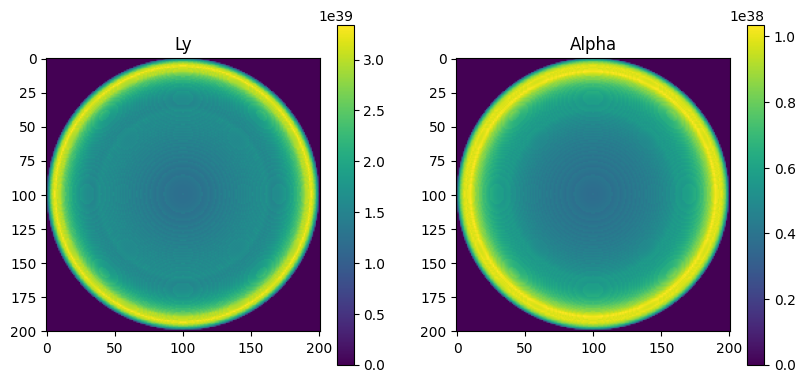

In [90]:
dim =201
n_cut = int((dim-1) /2)
proj_axis = 0
m3d = pc.C3D(list_of_models, dims = [dim, dim, dim], angles = [90,0,0], plan_sym = True)

plt.figure(figsize=(15,15))
plots(m3d, proj_axis)

In [92]:
model_name2 = "adapt2_13"

pc.log_.level = 3

set_models_second(model_name,model_name2,N,thickness_2,a_2_cm,a_2_cm,emis_tab,N_r,alpha_2,n0_2,r0_2_pc,C_2,sigma_2_rad,stop_logNH_2, ion_param_2, metals_2, stop_temp_2,dust_2)

../models/adapt_15_-90.txt
['dlaw table', '         17.479351      0.0000', '         18.540743      0.0000', 'end']
4.301029997835454
warng CloudyInput: "None" parameter not printed
     CloudyInput: Input writen in ../models/adapt2_13_-90.in
../models/adapt_15_-64.txt
['dlaw table', '         17.479351      0.1882', '         18.540743      0.1506', 'end']
3.9839984924923297
warng CloudyInput: "None" parameter not printed
     CloudyInput: Input writen in ../models/adapt2_13_-64.in
../models/adapt_15_-39.txt
['dlaw table', '         17.479351      1.9844', '         18.540743      1.5878', 'end']
2.8648355351464128
warng CloudyInput: "None" parameter not printed
     CloudyInput: Input writen in ../models/adapt2_13_-39.in
../models/adapt_15_-13.txt
['dlaw table', '         17.479351      4.7981', '         18.540743      3.8392', 'end']
-0.2672935113498084
warng CloudyInput: "None" parameter not printed
     CloudyInput: Input writen in ../models/adapt2_13_-13.in
../models/adapt_15_1

In [93]:
import multiprocessing
theta=np.linspace(-90.,90.,N)

model_names = [f"model2_{round(th)}" for th in theta]
print(model_names)

def _run_model(name):
    m = globals()[name]
    m.run_cloudy(n_proc=1)
    return name

if __name__ == '__main__':
    nproc = min(len(model_names), multiprocessing.cpu_count()-1) 
    with multiprocessing.Pool(processes=nproc) as pool:
        results = pool.map(_run_model, model_names)
    print("Terminados:", results)


['model2_-90', 'model2_-64', 'model2_-39', 'model2_-13', 'model2_13', 'model2_39', 'model2_64', 'model2_90']
     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_-90     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_-64     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_-39     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_-13     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_13     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_39     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_64     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_90







     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_39
     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt2_13_-39
     run_cloudy: ending:  /home/jorge/cloudy-src

In [94]:


list_of_models2 = pc.load_models('{0}/{1}'.format(dir_, model_name2), 
                                 list_elem=['H'],  
                                 read_cont = True, read_grains = False, 
                                 cloudy_version_major=24)


     CloudyModel ../models/adapt2_13_39: Creating CloudyModel for ../models/adapt2_13_39
     CloudyModel ../models/adapt2_13_39: ../models/adapt2_13_39.rad read
     CloudyModel ../models/adapt2_13_39: Number of zones: 408
     CloudyModel ../models/adapt2_13_39: ../models/adapt2_13_39.phy read
     CloudyModel ../models/adapt2_13_39: ../models/adapt2_13_39.ele_H read
     CloudyModel ../models/adapt2_13_39: filling H with 3 columns
     CloudyModel ../models/adapt2_13_39: ../models/adapt2_13_39.emis read
     CloudyModel ../models/adapt2_13_39: Number of emissivities: 2
     CloudyModel ../models/adapt2_13_39: ../models/adapt2_13_39.cont read
     CloudyModel ../models/adapt2_13_13: Creating CloudyModel for ../models/adapt2_13_13
     CloudyModel ../models/adapt2_13_13: ../models/adapt2_13_13.rad read
     CloudyModel ../models/adapt2_13_13: Number of zones: 491
     CloudyModel ../models/adapt2_13_13: ../models/adapt2_13_13.phy read
     CloudyModel ../models/adapt2_13_13: ../models

     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 90.0, 0.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method


<Figure size 1500x1500 with 0 Axes>

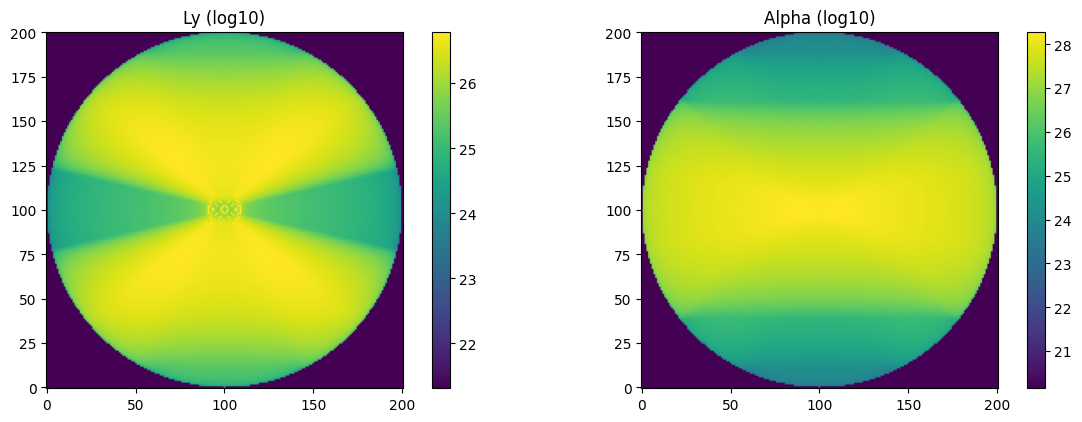

In [95]:
dim =201
n_cut = int((dim-1) /2)
proj_axis = 0

m3d2 = pc.C3D(list_of_models2, dims = [dim, dim, dim], angles = [90,0,0], plan_sym = True)

plt.figure(figsize=(15,15))
plotslog(m3d2, proj_axis) #When using grains for the cloud and the plot function, the image generated only shows some bright points. To solve this try repeating the simulaction without the grains just for the image or use plotslog instead.

In [75]:
for k,m in enumerate(list_of_models2):
    cx = m.get_cont_x(unit='Ang')
    print(k, getattr(m,'model_name', '<sin nombre>'), 'cont_x is', None if cx is None else f'len={len(cx)}')


0 ../models/adapt2_12_90 cont_x is len=9244
1 ../models/adapt2_12_-13 cont_x is len=9244
2 ../models/adapt2_12_-64 cont_x is len=9244
3 ../models/adapt2_12_39 cont_x is len=9244
4 ../models/adapt2_12_-90 cont_x is len=9244
5 ../models/adapt2_12_-39 cont_x is len=9244
6 ../models/adapt2_12_64 cont_x is len=9244
7 ../models/adapt2_12_13 cont_x is len=9244


     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 90.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 90.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method


/tmp/ipykernel_758/2138623711.py:259: RuntimeWarning: invalid value encountered in log10
  log_ha = np.log10(img_combined_ha + eps)
/tmp/ipykernel_758/2138623711.py:260: RuntimeWarning: invalid value encountered in log10
  log_ly = np.log10(img_combined_ly + eps)


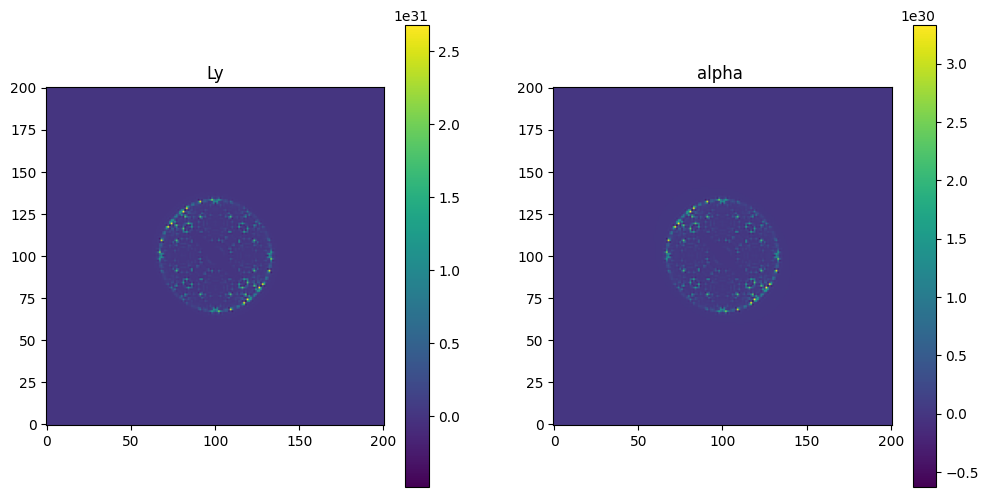

In [36]:
img_combined_ly,img_combined_ha=plots3(list_of_models,list_of_models2,dim=201,proj_axis=0,angles = [90,45, 0],rel_teo=Rin_1_pc/Rout_1_pc)

     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 45.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 45.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method

REFLECTION DIAGNOSTICS
  theta_proj range: [-60.00, 60.00]
  Total L_model_ly: 0.00e+00 erg/s
  Total L_refl_pix_ly: 0.00e+00 erg/s
  Energy conservation Ly: 0.0000
  Energy conservation Hα: 0.0000

 Theta (°) |  N_pix |      L_model |   L_assigned
------------------------------------------------

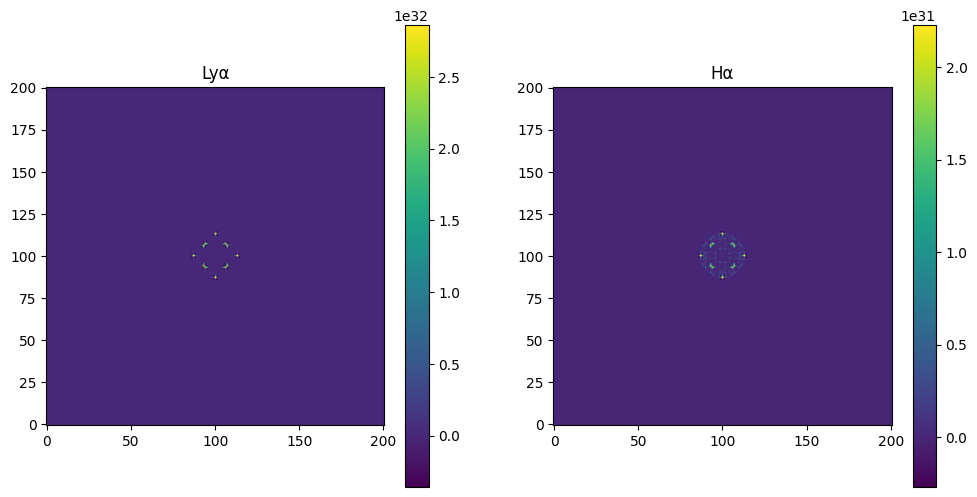

In [29]:

img_combined_ly2,img_combined_ha2=plots_reflection2_Fixed(list_of_models,list_of_models2,dim=201,proj_axis=2,angles = [45,45, 0],rel_teo=a_1_pc/a_2_pc,aumenta_refl=1.0)




In [10]:
model_name3 = "adapt3_5"
pc.log_.level = 3
#set_models_third(model_name2,model_name3,N,thickness_3,a_3_cm,a_3_cm,emis_tab,N_r,alpha=alpha_3,n0=n0_3,r0_pc=r0_3_pc,C=C_3,sigma_rad=sigma_3_rad,stop_logNH_3=stop_logNH_3, ion_param_3=ion_param_3)

In [ ]:
import multiprocessing
theta=np.linspace(-90.,90.,N)

model_names = [f"model3_{round(th)}" for th in theta]
print(model_names)

def _run_model(name):
    m = globals()[name]
    m.run_cloudy(n_proc=1)
    return name

if __name__ == '__main__':
    nproc = min(len(model_names), multiprocessing.cpu_count()-1)  
    with multiprocessing.Pool(processes=nproc) as pool:
        results = pool.map(_run_model, model_names)
    print("Terminados:", results)


['model3_-90', 'model3_-64', 'model3_-39', 'model3_-13', 'model3_13', 'model3_39', 'model3_64', 'model3_90']
     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_90     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_-39     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_13     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_-13     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_64     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_-64     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_39




     run_cloudy: running:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_-90


     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_-90     run_cloudy: ending:  /home/jorge/cloudy-src/source/cloudy.exe -p adapt3_5_90

     run_cloudy: ending:  /home/jorge/cloudy-src/source/cl

In [11]:
list_of_models3 = pc.load_models('{0}/{1}'.format(dir_, model_name3), 
                                 list_elem=['H'],  
                                 read_cont = True, read_grains = False, 
                                 cloudy_version_major=24)
                                
print(len(list_of_models3))

     CloudyModel ../models/adapt3_5_-64: Creating CloudyModel for ../models/adapt3_5_-64
     CloudyModel ../models/adapt3_5_-64: ../models/adapt3_5_-64.rad read
     CloudyModel ../models/adapt3_5_-64: Number of zones: 679
     CloudyModel ../models/adapt3_5_-64: ../models/adapt3_5_-64.phy read
     CloudyModel ../models/adapt3_5_-64: ../models/adapt3_5_-64.ele_H read
     CloudyModel ../models/adapt3_5_-64: filling H with 3 columns
     CloudyModel ../models/adapt3_5_-64: ../models/adapt3_5_-64.emis read
     CloudyModel ../models/adapt3_5_-64: Number of emissivities: 2
     CloudyModel ../models/adapt3_5_-64: ../models/adapt3_5_-64.cont read
     CloudyModel ../models/adapt3_5_64: Creating CloudyModel for ../models/adapt3_5_64
     CloudyModel ../models/adapt3_5_64: ../models/adapt3_5_64.rad read
     CloudyModel ../models/adapt3_5_64: Number of zones: 679
     CloudyModel ../models/adapt3_5_64: ../models/adapt3_5_64.phy read
     CloudyModel ../models/adapt3_5_64: ../models/adapt3_

     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 0.0, 90.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method


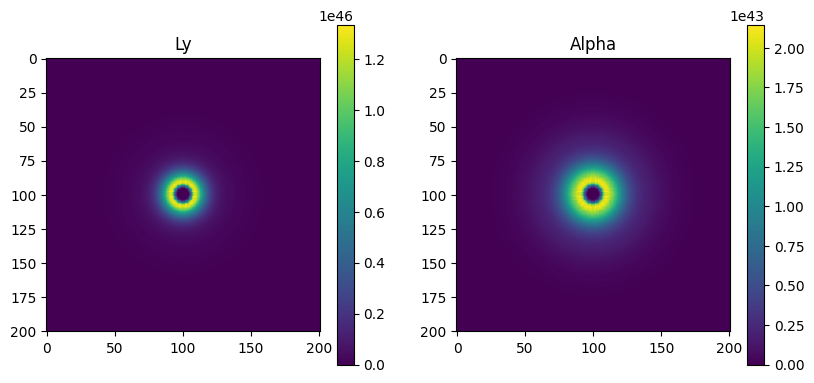

In [11]:
dim =201
n_cut = int((dim-1) /2)
proj_axis = 0

m3d3 = pc.C3D(list_of_models3, dims = [dim, dim, dim], angles = [0,90,0], plan_sym = True)

plt.figure(figsize=(15,15))
plots(m3d3, proj_axis)

In [67]:
for k,m in enumerate(list_of_models3):
    cx = m.get_cont_x(unit='Ang')
    print(k, getattr(m,'model_name', '<sin nombre>'), 'cont_x is', None if cx is None else f'len={len(cx)}')

0 ../models/adapt3_5_-64 cont_x is len=9244
1 ../models/adapt3_5_64 cont_x is len=9244
2 ../models/adapt3_5_-13 cont_x is len=9244
3 ../models/adapt3_5_-39 cont_x is len=9244
4 ../models/adapt3_5_13 cont_x is len=9244
5 ../models/adapt3_5_39 cont_x is len=9244


     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 135.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 135.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset

GEOMETRÍA
  cell_linear: 3.394150e+19 cm
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method

EMISIVIDAD:
  L_inner (Lyα): 1.416531e+53 erg/s
  L_outer (Lyα): 1.182555e+49 erg/s

ATENUACIÓN:
  L_inner atenuado (Lyα): 1.039332e+51 erg/s
  Transmisión media: 0.093818

RADIOS FÍSICOS:
  R_outer (de modelos): [3.39424085e+21, 3.39424085e+21, 3.39424

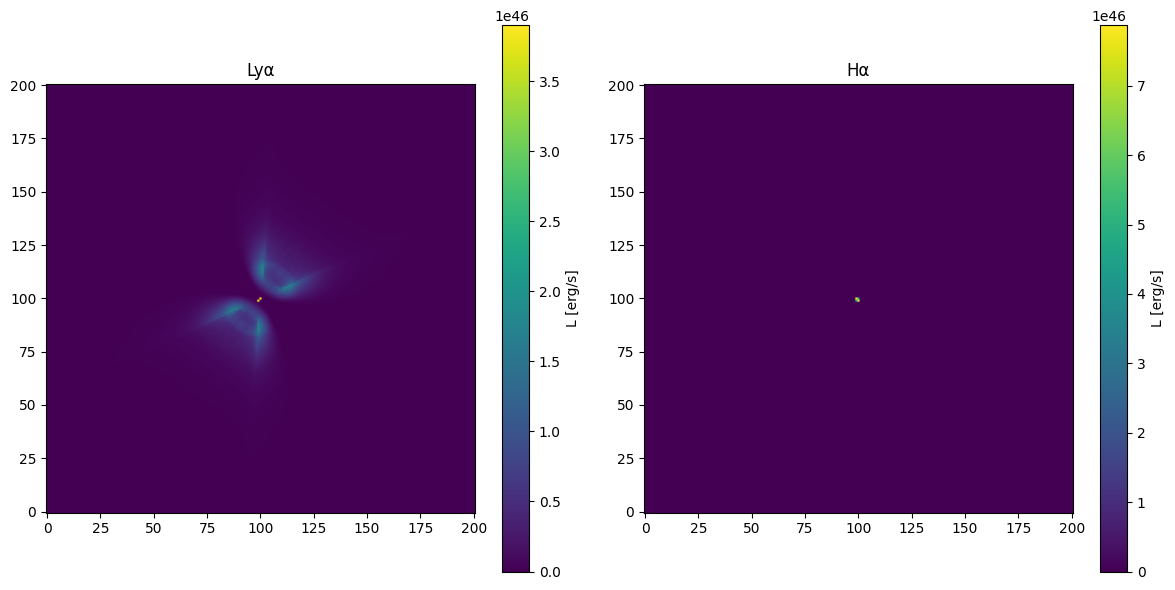

In [70]:
img_combined_ly,img_combined_ha=plots3_simple_FIXED(list_of_models2,list_of_models3,dim=201,proj_axis=1,angles = [135,45, 0],rel_teo=a_3_pc/a_2_pc)

     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 45.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: Entering C3D
     CubCoord: building a cube of 201x201x201
     CubCoord: Rotation matrix by 45.0, 45.0, 0.0 degrees.
     C3D: CubCoord done.
     C3D: interp_bi done.
     C3D: Interpolation mesh done
     C3D: All 3D values reset
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(0) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method
     C3D: get_emis(1) interpolated using numpy-method

=== DIAGNÓSTICO REFLEXIÓN ===
theta_proj range: [-60.63, 60.63]
Total L_model_ly: 4.29e+08 erg/s
Total L_refl_pix_ly: 4.94e+50 erg/s
Conservación energía Ly: 1.0000
Conservación energía Hα: 1.0000
  θ=-64.3°: 6784 pix, L_model=2.14e+08, L_asignada=2.47e+50
  θ= 64.3°: 6784 pix, L_model=2.14e+08, 

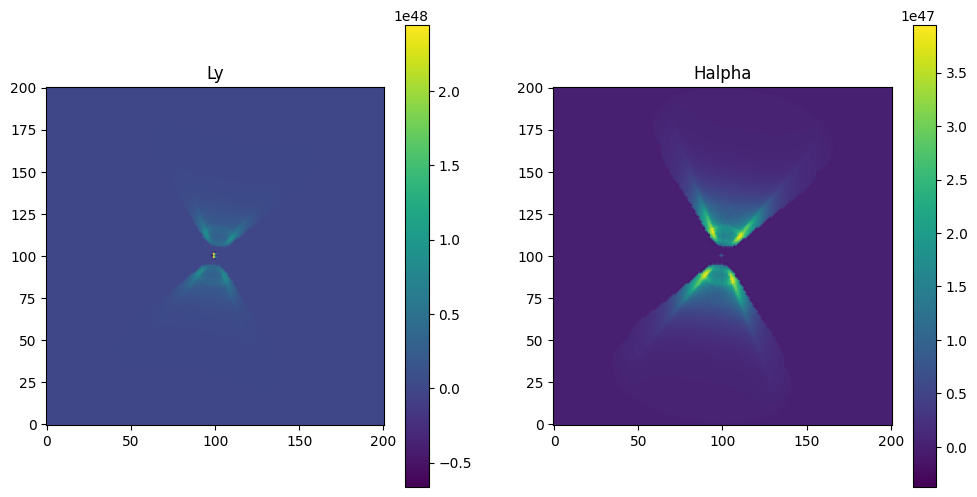

In [ ]:

img_combined_ly3,img_combined_ha3=plots_reflection2_Fixed(list_of_models2,list_of_models3,dim=201,proj_axis=2,angles = [45,45, 0],rel_teo=a_2_pc/a_3_pc,aumenta_refl=1000.0)


5.4925060924e+26


/tmp/ipykernel_758/2384126347.py:49: RuntimeWarning: divide by zero encountered in log10
  ax.plot(cont_x, np.log10(Cont_at_Earth), color=color, linewidth=1.5,


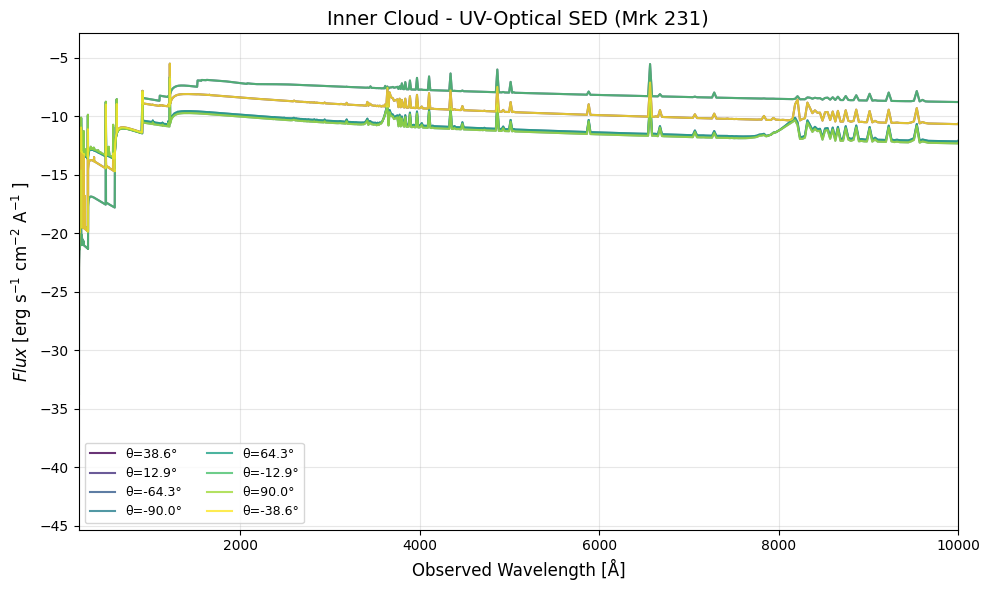

3.2005094535534797e-06


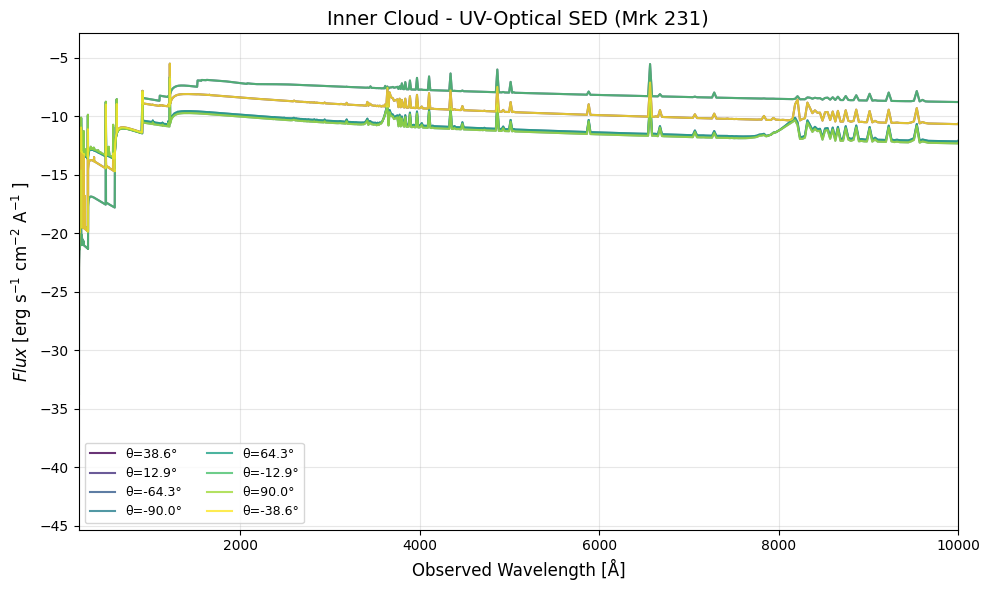

In [101]:
print(dist_earth_cm)
def plot_continuum(model_list, model_name):
    """
    Creates a plot similar to Figure 3 of Veilleux et al. (2013).
    
    Args:
        model_list: list of Cloudy model objects
        model_name: base name for the plot title
    
    Returns:
        fig: matplotlib figure object
    """

    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get colormap for different angles
    cmap = plt.cm.viridis
    N = len(model_list)
    
    # Plot each model
    for i, model in enumerate(model_list):
        # Get wavelength grid (in Angstroms)
        cont_x = model.get_cont_x(unit='Ang')
        
        if cont_x is None:
            print(f"Warning: No continuum data for model {i}")
            continue
        
        # Get transmitted continuum at Earth
        Cont_at_Earth = model.get_cont_y(cont='ntrans', unit='esA', dist_norm='at_earth') 
        #It should be esAc units but I think if we put esAc it normalices the continuum again as I think the continuum it is using as SED is already normalized to the distance from earth.
        
        if Cont_at_Earth is None:
            print(f"Warning: No transmitted continuum for model {i}")
            continue
        
        # Convert to lambda * F_lambda (for log-log plot like Figure 3)
        lambda_Flambda = cont_x * Cont_at_Earth
        
        # Get theta angle if available
        theta = getattr(model, 'theta', i)
        
        # Plot with color from colormap
        color = cmap(i / max(1, N - 1))
        #ax.loglog(cont_x, Cont_at_Earth, color=color, linewidth=1.5, 
                 #label=f'θ={theta:.1f}°', alpha=0.8)
       
        ax.plot(cont_x, np.log10(Cont_at_Earth), color=color, linewidth=1.5, 
                 label=f'θ={theta:.1f}°', alpha=0.8)
        #np.savetxt(f"{dir_}/cont_{theta}.txt", Cont_at_Earth, fmt="%.6e")
        
    # Format like Figure 3 of Veilleux et al. (2013)
    ax.set_xlabel('Observed Wavelength [Å]', fontsize=12)
    ax.set_xlim(200, 10000)
    #ax.set_ylim(0, np.max(lambda_Flambda)*1.1)
    #ax.set_ylabel('log $\\lambda F_{\\lambda}$ [erg s$^{-1}$ cm$^{-2}$]', fontsize=12)
    ax.set_ylabel('$Flux$ [erg s$^{-1}$ cm$^{-2}$ A$^{-1}$ ]', fontsize=12)
    ax.set_title(f'{model_name} - UV-Optical SED (Mrk 231)', fontsize=14)
    ax.legend(fontsize=9, ncol=2, loc='best')
    ax.grid(True, alpha=0.3, which='both')
    
    plt.tight_layout()
    plt.show()
    print(np.max(Cont_at_Earth))
    
    return fig


plot_continuum(list_of_models2, model_name="Inner Cloud")


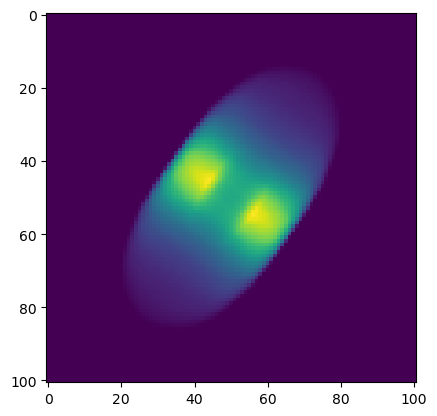

In [ ]:
plt.imshow(m3d.get_emis('O__3_500684A').sum(axis=2))